# Image Sharing Analysis
Rebuilding the essential graphs for the dissertation chapter.

In [257]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create a folder to save all the graphs directly into the dissertation folder
os.makedirs('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6', exist_ok=True)

img_df = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_image_data_feb_25.csv')
book_df = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_book_data_feb_25.csv')
geo_df = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_image_data_feb_25_corrected_centrality_earth.csv')

# Map place names to coordinates
geo_map = geo_df.drop_duplicates(subset=['place'])[['place', 'latitude', 'longitude']]

# Get unique images list safely avoiding duplicates within a single book's printing
img_u = img_df.drop(columns=['latitude', 'longitude'], errors='ignore').drop_duplicates(subset=['images','cluster_name','bid']).copy()
img_u = img_u.merge(book_df[['bid','publishers','printers']], on='bid', how='left')
img_u = img_u.merge(geo_map, on='place', how='left')
print(f'Loaded {len(img_df):,} total images, reduced to {len(img_u):,} unique instances across {img_u["bid"].nunique():,} books.')


Loaded 27,981 total images, reduced to 20,540 unique instances across 342 books.


### Graph 0 — Distribution of Image Cluster Sizes

How many images are perfectly unique vs shared across books?

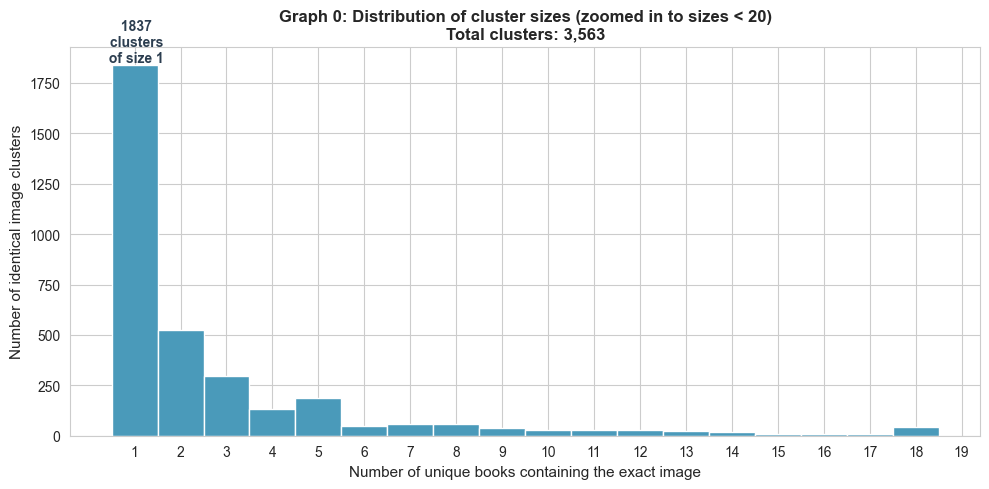

Image clusters that only appear in 1 book (never shared): 1,837 (51.6%)
Image clusters shared across >1 book: 1,726 (48.4%)
The most widespread image cluster appears in 133 books.


In [258]:
# Count how many total images (rows) are in each cluster
# Note: using the raw image dataframe to see total occurrences
cluster_sizes = img_df.groupby('cluster_name')['bid'].nunique()

fig, ax = plt.subplots(figsize=(10, 5))
bins = range(1, 20)
ax.hist(cluster_sizes[cluster_sizes < 20], bins=bins, color='#4a9aba', edgecolor='white', align='left')
ax.set_xticks(range(1, 20))

# Add text annotation for the huge number of size-1 clusters
size_1_count = sum(cluster_sizes == 1)
if size_1_count > 0:
    ax.text(1, size_1_count, f' {size_1_count}\n clusters\n of size 1', 
            va='bottom', ha='center', fontsize=10, color='#2c3e50', fontweight='bold')

ax.set_xlabel('Number of unique books containing the exact image', fontsize=11)
ax.set_ylabel('Number of identical image clusters', fontsize=11)
ax.set_title('Graph 0: Distribution of cluster sizes (zoomed in to sizes < 20)\n'
             f'Total clusters: {len(cluster_sizes):,}', fontsize=12, fontweight='bold')

plt.tight_layout()

# Save the figure to the graphs folder
fig.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/Graph_0_Cluster_Sizes.png', dpi=300, bbox_inches='tight')

plt.show()

print(f"Image clusters that only appear in 1 book (never shared): {size_1_count:,} ({100 * size_1_count / len(cluster_sizes):.1f}%)")
print(f"Image clusters shared across >1 book: {len(cluster_sizes) - size_1_count:,} ({100 * (len(cluster_sizes) - size_1_count) / len(cluster_sizes):.1f}%)")
print(f"The most widespread image cluster appears in {cluster_sizes.max():,} books.")




### Graph 1 — Sharing of Content Keywords (CKs)

Instead of exact image copies, we can group images by theme. There are 168 distinct 'Content Keyword' (CK) tags. How many books feature each of these thematic subjects at least once?

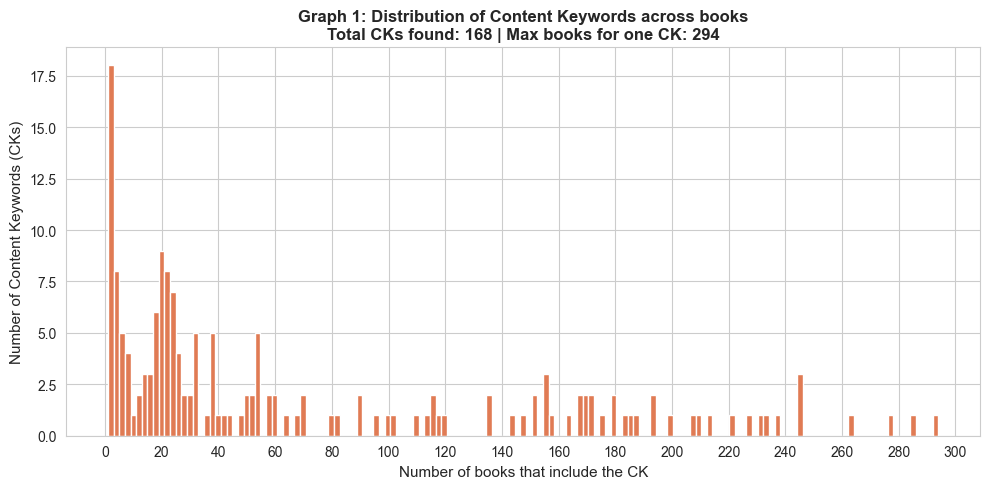

Top 5 most widely printed Content Keywords:
 - CK_Lunar Eclipse: appears in 294 books
 - CK_Right and Oblique Sphere: appears in 286 books
 - CK_Five Zones: appears in 278 books
 - CK_Solar Eclipse: appears in 264 books
 - CK_Sphericity of the Water Element: appears in 246 books

26 CKs (15.5%) appear in fewer than 5 books.


In [259]:
# Extract CKs from each image and map them to the books that contain them
ck_book_map = {}
for _, row in img_df.dropna(subset=['cks']).iterrows():
    bid = row['bid']
    # Split by comma in case multiple CKs are listed
    cks_list = [ck.strip() for ck in str(row['cks']).split(',') if ck.strip()]
    for ck in cks_list:
        if ck not in ck_book_map:
            ck_book_map[ck] = set()
        ck_book_map[ck].add(bid)

# Count how many unique books feature each CK
ck_counts = pd.Series({ck: len(bids) for ck, bids in ck_book_map.items()})

fig, ax = plt.subplots(figsize=(10, 5))
# We'll use 20 bins to show the spread
max_val = int(ck_counts.max())
step = 10 if max_val <= 100 else 20
ax.hist(ck_counts, bins=int(max_val/2), color='#e07b54', edgecolor='white')
ax.set_xticks(range(0, max_val + step, step))

ax.set_xlabel('Number of books that include the CK', fontsize=11)
ax.set_ylabel('Number of Content Keywords (CKs)', fontsize=11)
ax.set_title(f'Graph 1: Distribution of Content Keywords across books\n'
             f'Total CKs found: {len(ck_counts)} | Max books for one CK: {ck_counts.max()}',
             fontsize=12, fontweight='bold')

plt.tight_layout()

# Save the graph
fig.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/Graph_1_CK_Sharing.png', dpi=300, bbox_inches='tight')

plt.show()

# Print out some interesting outliers (the most common CKs)
top_cks = ck_counts.sort_values(ascending=False).head(5)
print("Top 5 most widely printed Content Keywords:")
for ck, count in top_cks.items():
    print(f" - {ck}: appears in {count} books")

# Print how many CKs appear in fewer than 5 books
rare_cks = sum(ck_counts < 5)
print(f"\n{rare_cks} CKs ({100*rare_cks/len(ck_counts):.1f}%) appear in fewer than 5 books.")





### Graph 2 — Institutional Sharing (Printers/Publishers)

Focusing **only on images that were shared** (clusters appearing in >1 book), how many **different printing houses** (printers/publishers) used the exact same woodblock over its lifespan? This graph counts the shared image clusters by the number of unique institutional producers that printed them. A value of 1 means the shared woodblock stayed entirely within a single printing house.

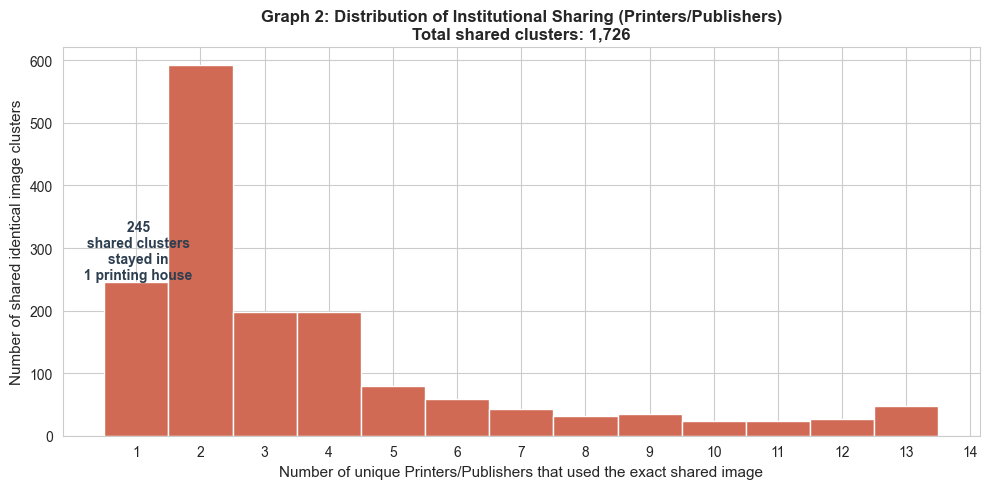

Shared clusters staying strictly within 1 printing house: 245 (14.2%)
Shared clusters moving across >1 printing house: 1,481 (85.8%)
The most widely circulated exact woodblock was used by 61 different printers/publishers.


In [260]:
# Filter to only clusters that appear in >1 book (shared clusters)
shared_clusters = cluster_sizes[cluster_sizes > 1].index
shared_df = img_u[img_u['cluster_name'].isin(shared_clusters)].copy()

# Create a combined 'producer' field (publisher + printer)
shared_df['producer'] = shared_df['publishers'].fillna('') + " | " + shared_df['printers'].fillna('')

# Count how many unique producers printed each SHARED cluster
producer_counts = shared_df.groupby('cluster_name')['producer'].nunique(dropna=True)

fig, ax = plt.subplots(figsize=(10, 5))
bins = range(1, 15)
ax.hist(producer_counts[producer_counts < 15], bins=bins, color='#d16a54', edgecolor='white', align='left')
ax.set_xticks(range(1, 15))

# Add text annotation
size_1_count = sum(producer_counts == 1)
if size_1_count > 0:
    ax.text(1, size_1_count, f' {size_1_count:,}\n shared clusters\n stayed in\n 1 printing house', 
            va='bottom', ha='center', fontsize=10, color='#2c3e50', fontweight='bold')

ax.set_xlabel('Number of unique Printers/Publishers that used the exact shared image', fontsize=11)
ax.set_ylabel('Number of shared identical image clusters', fontsize=11)
ax.set_title('Graph 2: Distribution of Institutional Sharing (Printers/Publishers)\n'             f'Total shared clusters: {len(producer_counts):,}', fontsize=12, fontweight='bold')

plt.tight_layout()

# Save the figure to the graphs folder
fig.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/Graph_2_Producer_Sharing.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
prop_shared_inst = sum(producer_counts > 1) / len(producer_counts) * 100
print(f"Shared clusters staying strictly within 1 printing house: {size_1_count:,} ({100 - prop_shared_inst:.1f}%)")
print(f"Shared clusters moving across >1 printing house: {sum(producer_counts > 1):,} ({prop_shared_inst:.1f}%)")
print(f"The most widely circulated exact woodblock was used by {producer_counts.max()} different printers/publishers.")


### Graph 3 — Geographic Sharing (Cities) across Different Print Houses

Focusing **only on images that were shared across DIFFERENT printing houses** (where the exact woodblock moved from one printer/publisher to another), how many **different cities** did the physical woodblock travel to? This graph counts those mobile image clusters by the number of distinct cities they were printed in. A value of 1 means the shared woodblock moved between different printing houses, but never left its city of origin.

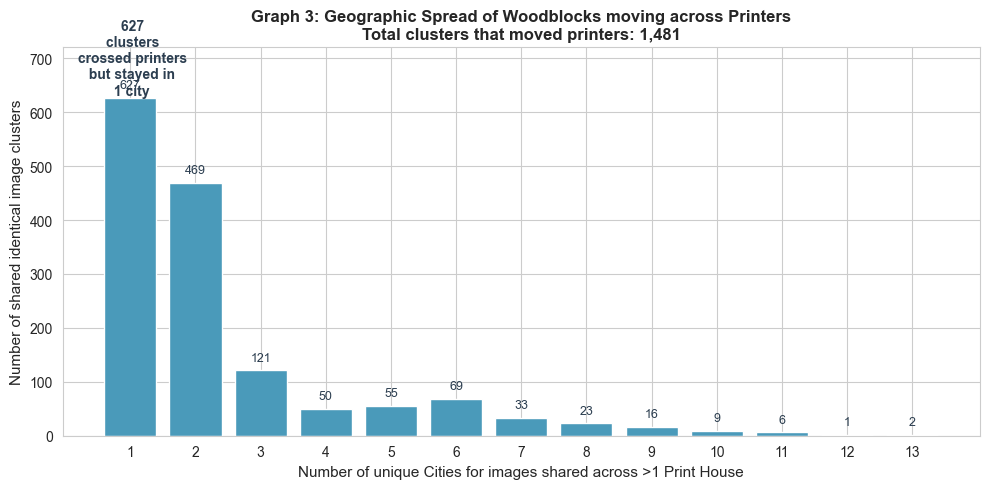

Clusters that moved printers but stayed strictly within 1 city: 627 (42.3%)
Clusters that moved printers AND moved across >1 city: 854 (57.7%)
The most widely traveled exact woodblock was used in 13 different cities.


In [261]:
# Filter to ONLY clusters that crossed institutional boundaries (>1 unique producer)
inst_cross_clusters = producer_counts[producer_counts > 1].index
graph3_df = shared_df[shared_df['cluster_name'].isin(inst_cross_clusters)].copy()

# Count how many unique places (cities) printed each of these mobile clusters
place_counts = graph3_df.groupby('cluster_name')['place'].nunique(dropna=True)

# Use value_counts to explicitly get the counts per number of cities
counts = place_counts.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(counts.index, counts.values, color='#4a9aba', edgecolor='white')

# Add exact count on top of every bar
for x, y in zip(counts.index, counts.values):
    ax.text(x, y + counts.max()*0.02, f'{y:,}', ha='center', va='bottom', fontsize=9, color='#2c3e50')

# Ensure X axis has a tick for every integer from 1 to the max number of cities
max_cities = max(counts.index.max(), 10)
ax.set_xticks(range(1, max_cities + 1))
ax.set_ylim(0, counts.values.max() * 1.15)

# Add text annotation
size_1_count_place = counts.get(1, 0)
if size_1_count_place > 0:
    ax.text(1, size_1_count_place, f' {size_1_count_place:,}\n clusters\n crossed printers\n but stayed in\n 1 city', 
            va='bottom', ha='center', fontsize=10, color='#2c3e50', fontweight='bold')

ax.set_xlabel('Number of unique Cities for images shared across >1 Print House', fontsize=11)
ax.set_ylabel('Number of shared identical image clusters', fontsize=11)
ax.set_title('Graph 3: Geographic Spread of Woodblocks moving across Printers\n'             f'Total clusters that moved printers: {len(place_counts):,}', fontsize=12, fontweight='bold')

plt.tight_layout()

# Save the figure
fig.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/Graph_3_City_Sharing.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
prop_shared_city = sum(place_counts > 1) / len(place_counts) * 100
print(f"Clusters that moved printers but stayed strictly within 1 city: {size_1_count_place:,} ({100 - prop_shared_city:.1f}%)")
print(f"Clusters that moved printers AND moved across >1 city: {sum(place_counts > 1):,} ({prop_shared_city:.1f}%)")
print(f"The most widely traveled exact woodblock was used in {place_counts.max()} different cities.")


### Graph 4 — Geographic and Institutional Distance of Image Sharing Over Time

How did the nature of image sharing change over time? In this analysis, we identify the **origin** of every shared image cluster (its earliest known printing). For every subsequent copy in the dataset, we calculate two metrics:
1. **Geographic Distance**: The flight distance (in km) between the printing city of the copy and the origin city.
2. **Institutional Sharing (Red Line)**: Out of all the copies printed in that decade, what percentage were printed by a *new/different* printing house rather than the printing house that originally created the block?

By aggregating these metrics by decade, we can see if image sharing became more geographically dispersed and institutionally fluid over time.

Task was destroyed but it is pending!
task: <Task pending name='Task-2158' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-2159' coro=<Kernel.shell_main() running at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/cycler/__init__.py:438: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  out: dict[K, list[V]] = {k: list() for k in keys}
Task was destroyed but it is pending!
task: <Task pending name='Task-2159' coro=<Kernel.shell_main() running at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/i

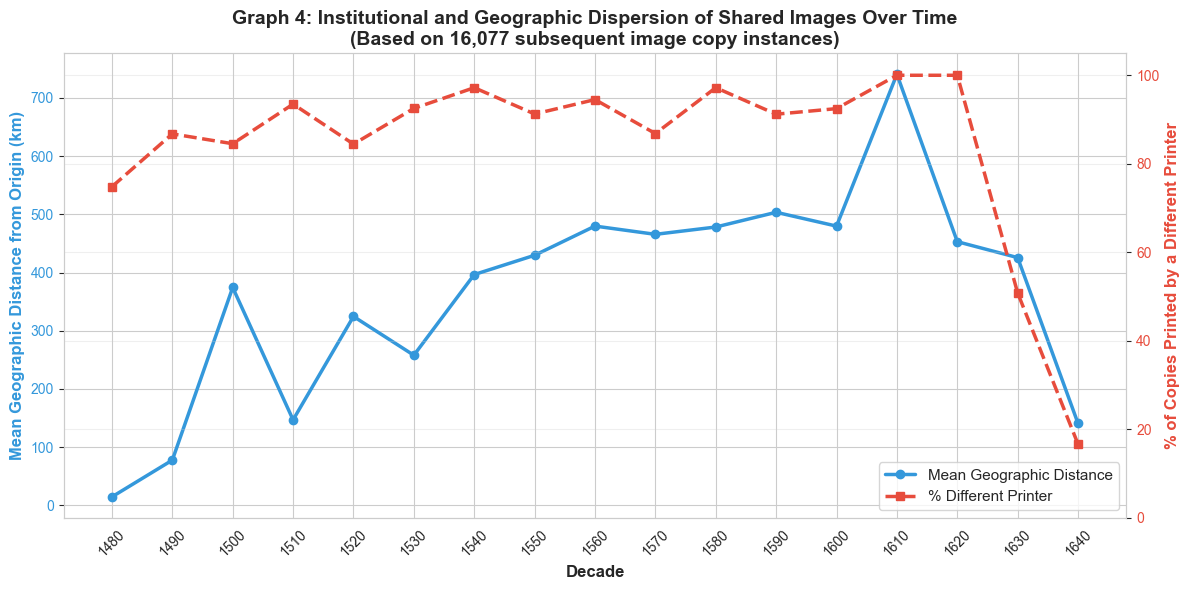

In [295]:
import numpy as np

# Retain only clusters that are shared
cluster_sizes_time = img_u.groupby('cluster_name')['bid'].nunique()
shared_clusters_time = cluster_sizes_time[cluster_sizes_time > 1].index
time_df = img_u[img_u['cluster_name'].isin(shared_clusters_time)].copy()

# Ensure we have coordinates and years
time_df = time_df.dropna(subset=['year', 'latitude', 'longitude'])
time_df['year'] = pd.to_numeric(time_df['year'], errors='coerce')
time_df = time_df.dropna(subset=['year'])

# Create unified producer
time_df['producer'] = time_df['publishers'].fillna('') + " | " + time_df['printers'].fillna('')

# Define Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371 # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Identify the absolute "origin" instance of each cluster (earliest year)
origins = time_df.loc[time_df.groupby('cluster_name')['year'].idxmin()]
origins = origins[['cluster_name', 'producer', 'latitude', 'longitude', 'year']].rename(columns={
    'producer': 'orig_prod',
    'latitude': 'orig_lat',
    'longitude': 'orig_lon',
    'year': 'orig_year'
})

# Merge origins back into main DataFrame
time_df = time_df.merge(origins, on='cluster_name', how='left')

# Exclude the "origin" printings themselves, only look at the subsequent COPIES
copies = time_df[time_df['year'] > time_df['orig_year']].copy()

# Calculate metrics for each copy
copies['is_diff_producer'] = (copies['producer'] != copies['orig_prod']).astype(int)
copies['distance_to_origin'] = haversine(
    copies['latitude'].values, copies['longitude'].values, 
    copies['orig_lat'].values, copies['orig_lon'].values
)

# Group by Decade
copies['decade'] = (copies['year'] // 10) * 10
decade_stats = copies.groupby('decade').agg(
    total_copies=('bid', 'count'),
    pct_diff_producer=('is_diff_producer', 'mean'),
    mean_distance=('distance_to_origin', 'mean')
).reset_index()

# Convert to percentage
decade_stats['pct_diff_producer'] *= 100

# Exclude decades with very few data points (< 30) to avoid extreme outliers
decade_stats = decade_stats[decade_stats['total_copies'] >= 30]

# Plotting with dual Y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = '#3498db'
ax1.set_xlabel('Decade', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Geographic Distance from Origin (km)', color=color1, fontsize=12, fontweight='bold')
line1 = ax1.plot(decade_stats['decade'], decade_stats['mean_distance'], color=color1, marker='o', linewidth=2.5, label='Mean Geographic Distance')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(decade_stats['decade'])
ax1.set_xticklabels(decade_stats['decade'].astype(int), rotation=45)

# Secondary Y-axis for percentage
ax2 = ax1.twinx()  
color2 = '#e74c3c'
ax2.set_ylabel('% of Copies Printed by a Different Printer', color=color2, fontsize=12, fontweight='bold')  
line2 = ax2.plot(decade_stats['decade'], decade_stats['pct_diff_producer'], color=color2, marker='s', linewidth=2.5, linestyle='--', label='% Different Printer')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 105) # Percentage axis

# Title and Layout
plt.title('Graph 4: Institutional and Geographic Dispersion of Shared Images Over Time\n'          f'(Based on {len(copies):,} subsequent image copy instances)', fontsize=14, fontweight='bold')

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=11)

plt.grid(alpha=0.3)
plt.tight_layout()

# Save the figure
fig.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/Graph_4_Time_Dispersion.png', dpi=300, bbox_inches='tight')
plt.show()


### Graph 5 — Maximum Geographic Spread per Shared Image Cluster

For every image cluster that was printed in more than one book, what was the **maximum geographic distance** it traveled? By computing the greatest distance between any two cities where a specific woodblock was printed, we can see the distribution of how far images circulated. Images that were shared but never left their origin city have a spread of 0 km.

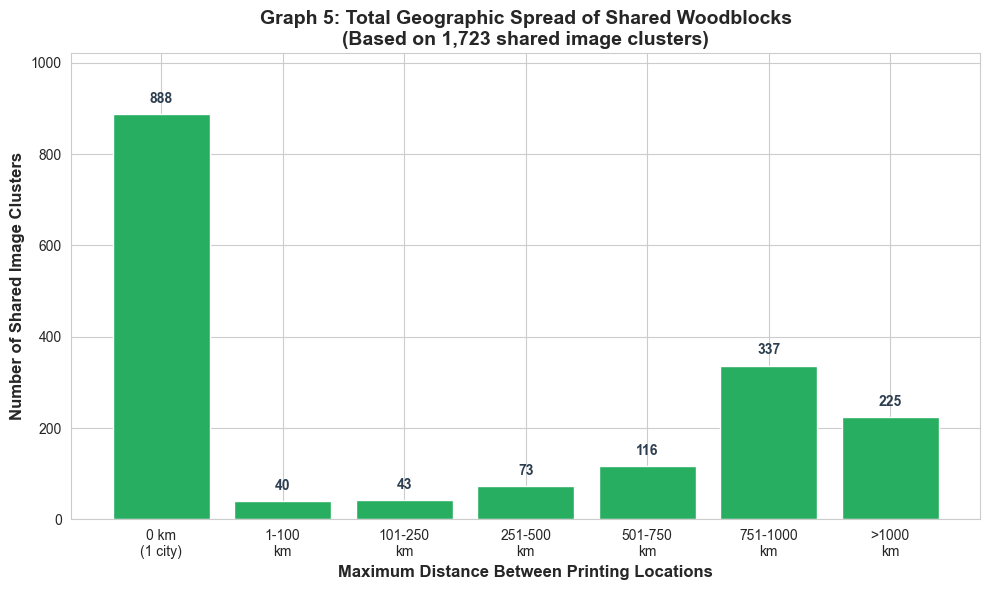

Clusters that were shared but never left their origin city: 888 (51.5%)
Clusters that spread across Europe (>750 km): 562 (32.6%)


In [296]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Filter to shared clusters only
cluster_sizes_spread = img_u.groupby('cluster_name')['bid'].nunique()
shared_clusters_spread = cluster_sizes_spread[cluster_sizes_spread > 1].index
spread_df = img_u[img_u['cluster_name'].isin(shared_clusters_spread)].copy()
spread_df = spread_df.dropna(subset=['latitude', 'longitude', 'place'])

def haversine(lat1, lon1, lat2, lon2):
    R = 6371 # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Get unique lat/lons per cluster to compute pairwise distances
places = spread_df.drop_duplicates(subset=['cluster_name', 'place'])[['cluster_name', 'latitude', 'longitude']].copy()

max_distances = {}
for cluster, group in places.groupby('cluster_name'):
    coords = group[['latitude', 'longitude']].values
    if len(coords) < 2:
        max_distances[cluster] = 0
        continue
    
    # Calculate all pairwise distances to find the maximum physical spread
    n = len(coords)
    max_d = 0
    for i in range(n):
        for j in range(i+1, n):
            d = haversine(coords[i][0], coords[i][1], coords[j][0], coords[j][1])
            if d > max_d:
                max_d = d
    max_distances[cluster] = max_d

d_series = pd.Series(max_distances)

# Bin the maximum distances
bins = [-1, 0, 100, 250, 500, 750, 1000, 5000]
labels = ['0 km\n(1 city)', '1-100\nkm', '101-250\nkm', '251-500\nkm', '501-750\nkm', '751-1000\nkm', '>1000\nkm']
cats = pd.cut(d_series, bins=bins, labels=labels)
counts = cats.value_counts().reindex(labels)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(counts.index, counts.values, color='#27ae60', edgecolor='white')

# Add exact count on top of every bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + counts.values.max()*0.02, f'{yval:,}', 
            ha='center', va='bottom', fontsize=10, color='#2c3e50', fontweight='bold')

ax.set_ylim(0, counts.values.max() * 1.15)
ax.set_xlabel('Maximum Distance Between Printing Locations', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Shared Image Clusters', fontsize=12, fontweight='bold')
ax.set_title('Graph 5: Total Geographic Spread of Shared Woodblocks\n'             f'(Based on {len(d_series):,} shared image clusters)', fontsize=14, fontweight='bold')

plt.tight_layout()

# Save the figure
fig.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/Graph_5_Geo_Spread.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print(f"Clusters that were shared but never left their origin city: {counts.iloc[0]:,} ({counts.iloc[0]/len(d_series)*100:.1f}%)")
print(f"Clusters that spread across Europe (>750 km): {counts.iloc[-2] + counts.iloc[-1]:,} ({(counts.iloc[-2] + counts.iloc[-1])/len(d_series)*100:.1f}%)")


In [297]:
#Graph 5(B) — Geographic Spread of Woodblocks Shared Across Different Printers¶

#This visualization refines the geographic spread analysis by focusing exclusively on woodblocks that were shared across different printing houses (nunique printers > 1). This filters out woodblocks that were merely reused by the same printer for multiple editions of the same work, highlighting actual material exchange or copying between institutional actors.

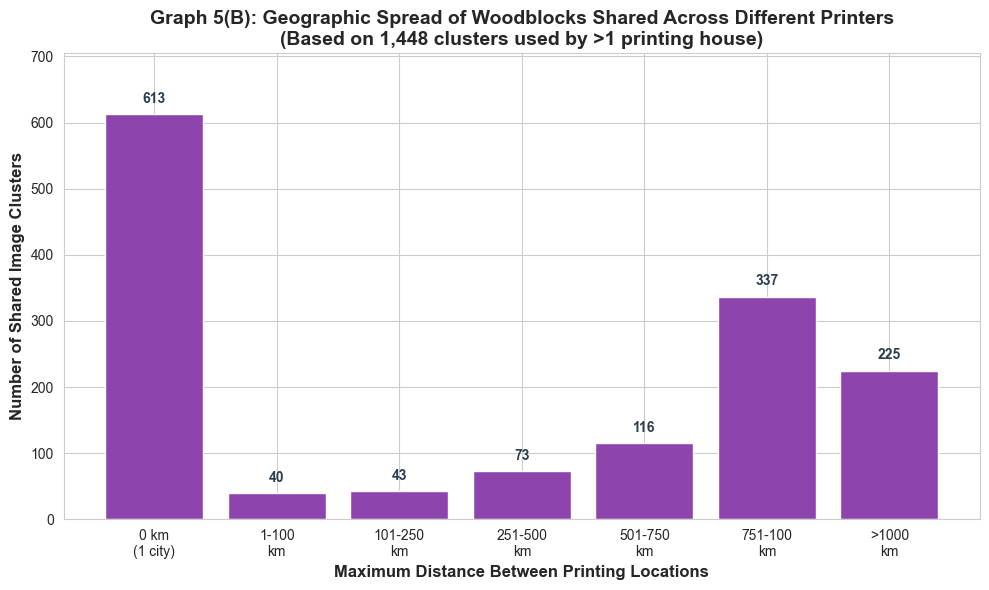

Clusters shared between printers but never left their city: 613 (42.3%)


In [298]:
# Filter to clusters shared across different INSTITUTIONS
cluster_printer_counts = img_u.groupby('cluster_name')['printers'].nunique()
mobile_clusters_inst = cluster_printer_counts[cluster_printer_counts > 1].index
spread_df_inst = img_u[img_u['cluster_name'].isin(mobile_clusters_inst)].copy()
spread_df_inst = spread_df_inst.dropna(subset=['latitude', 'longitude', 'place'])

# Compute pairwise distances for these "actually shared" woodblocks
places_inst = spread_df_inst.drop_duplicates(subset=['cluster_name', 'place'])[['cluster_name', 'latitude', 'longitude']].copy()

max_distances_inst = {}
for cluster, group in places_inst.groupby('cluster_name'):
    coords = group[['latitude', 'longitude']].values
    if len(coords) < 2:
        max_distances_inst[cluster] = 0
        continue
    
    n = len(coords)
    max_d = 0
    for i in range(n):
        for j in range(i+1, n):
            d = haversine(coords[i][0], coords[i][1], coords[j][0], coords[j][1])
            if d > max_d:
                max_d = d
    max_distances_inst[cluster] = max_d

d_series_inst = pd.Series(max_distances_inst)
bins = [-1, 0, 100, 250, 500, 750, 1000, 5000]
labels = ["0 km\n(1 city)", "1-100\nkm", "101-250\nkm", "251-500\nkm", "501-750\nkm", "751-100\nkm", ">1000\nkm"]
cats_inst = pd.cut(d_series_inst, bins=bins, labels=labels)
counts_inst = cats_inst.value_counts().reindex(labels)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(counts_inst.index, counts_inst.values, color='#8e44ad', edgecolor='white')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + counts_inst.values.max()*0.02, f'{yval:,}', 
            ha='center', va='bottom', fontsize=10, color='#2c3e50', fontweight='bold')

ax.set_ylim(0, counts_inst.values.max() * 1.15)
ax.set_xlabel('Maximum Distance Between Printing Locations', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Shared Image Clusters', fontsize=12, fontweight='bold')
ax.set_title("Graph 5(B): Geographic Spread of Woodblocks Shared Across Different Printers\n"
             f'(Based on {len(d_series_inst):,} clusters used by >1 printing house)', fontsize=14, fontweight='bold')

plt.tight_layout()
fig.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/Graph_5B_Institutional_Mobility.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Clusters shared between printers but never left their city: {counts_inst.iloc[0]:,} ({counts_inst.iloc[0]/len(d_series_inst)*100:.1f}%)")


### Graph 5(C) — Major Hubs in the Long-Distance Sharing Network (> 251 km)

To distinguish between the different roles cities play in the long-distance woodblock trade, we categorize every image cluster that traveled > 251 km. 

*   **Exports (Origin)**: The city where the high-mobility woodblock was first printed.
*   **Imports (Receiver)**: Cities that printed a woodblock originating from a distant hub.

This visualization highlights the **Innovation Hubs** that supplied the network and the **Distribution Hubs** that relied heavily on imported material.

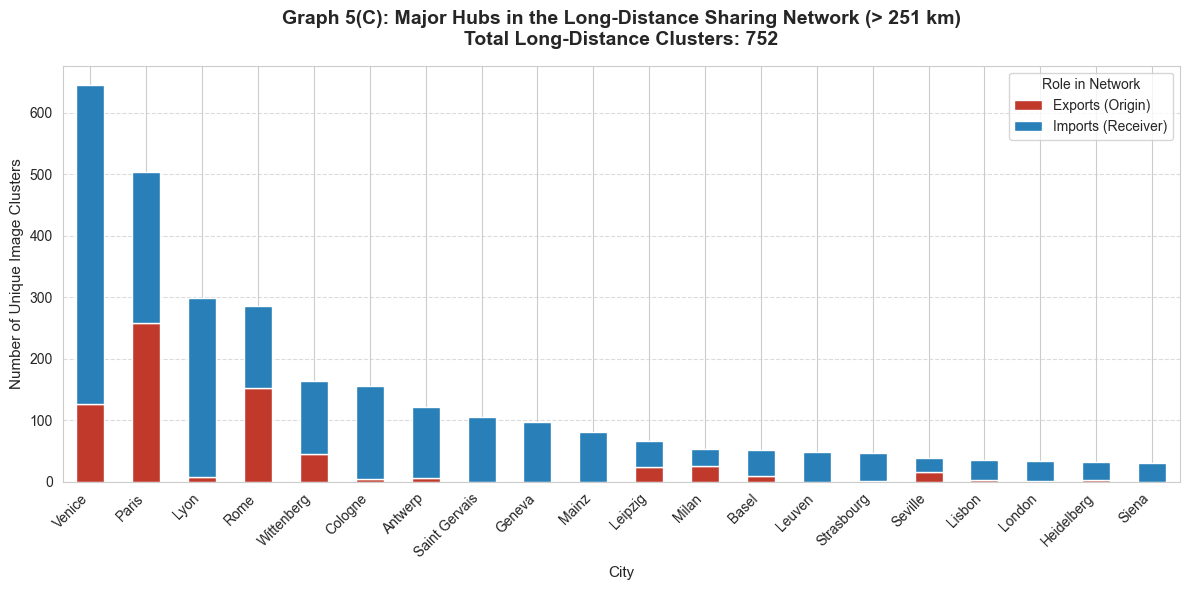

--- TOP 20 CITIES BY LONG-DISTANCE PARTICIPATION ---
               Exports (Origin)  Imports (Receiver)  Total
place                                                     
Venice                      126                 518    644
Paris                       258                 246    504
Lyon                          8                 291    299
Rome                        152                 133    285
Wittenberg                   45                 119    164
Cologne                       5                 150    155
Antwerp                       6                 116    122
Saint Gervais                 0                 105    105
Geneva                        0                  97     97
Mainz                         0                  81     81
Leipzig                      24                  43     67
Milan                        25                  28     53
Basel                        10                  42     52
Leuven                        0                  49     49
Str

In [299]:
# 1. Identify "Long-Distance" clusters (> 251 km max spread)
long_dist_clusters = d_series_inst[d_series_inst > 251].index

# 2. For each cluster, find the Origin (earliest year/bid)
long_dist_data = img_u[img_u["cluster_name"].isin(long_dist_clusters)].copy()
long_dist_data = long_dist_data.sort_values(["cluster_name", "year", "bid"])
cluster_origins = long_dist_data.groupby("cluster_name").first().reset_index()

# 3. Calculate "Exports" (when a city is the Origin)
exports = cluster_origins["place"].value_counts()

# 4. Calculate "Imports" (when a city prints it but is NOT the origin)
all_appearances = long_dist_data[["cluster_name", "place", "bid"]].drop_duplicates()
origin_ids = cluster_origins[["cluster_name", "bid"]].assign(is_origin=True)
all_appearances = all_appearances.merge(origin_ids, on=["cluster_name", "bid"], how="left")

import_data = all_appearances[all_appearances["is_origin"].isna()]
imports = import_data.groupby("place")["cluster_name"].nunique()

# 5. Combine into a Summary DF for Plotting
hub_summary = pd.DataFrame({
    "Exports (Origin)": exports,
    "Imports (Receiver)": imports
}).fillna(0).astype(int)

hub_summary["Total"] = hub_summary["Exports (Origin)"] + hub_summary["Imports (Receiver)"]
hub_summary = hub_summary.sort_values("Total", ascending=False).head(20)

# 6. Plot
fig, ax = plt.subplots(figsize=(12, 6))
# Re-sort for better visual to show stacked properly
hub_summary[["Exports (Origin)", "Imports (Receiver)"]].plot(
    kind="bar", stacked=True, ax=ax, color=["#c0392b", "#2980b9"], edgecolor="white"
)

ax.set_title("Graph 5(C): Major Hubs in the Long-Distance Sharing Network (> 251 km)\n"
             f"Total Long-Distance Clusters: {len(long_dist_clusters):,}", 
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Number of Unique Image Clusters", fontsize=11)
ax.set_xlabel("City", fontsize=11)
ax.legend(title="Role in Network")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/graph_5c_long_distance_hubs.png", dpi=300)
plt.show()

# Print Table for reference
print("--- TOP 20 CITIES BY LONG-DISTANCE PARTICIPATION ---")
print(hub_summary.to_string())


### Graph 6 — City Market Profile (Local vs. Shared Woodblocks)

This visualization shows the 'composition' of each city's woodblock repertoire. We distinguish between **Local** images (found only in that city) and **Shared** images (mobile clusters circulating across Europe). This clarifies the Hub-and-Spoke dynamic: Hubs have balanced repertoires with high innovation, while Spokes rely entirely on shared material.

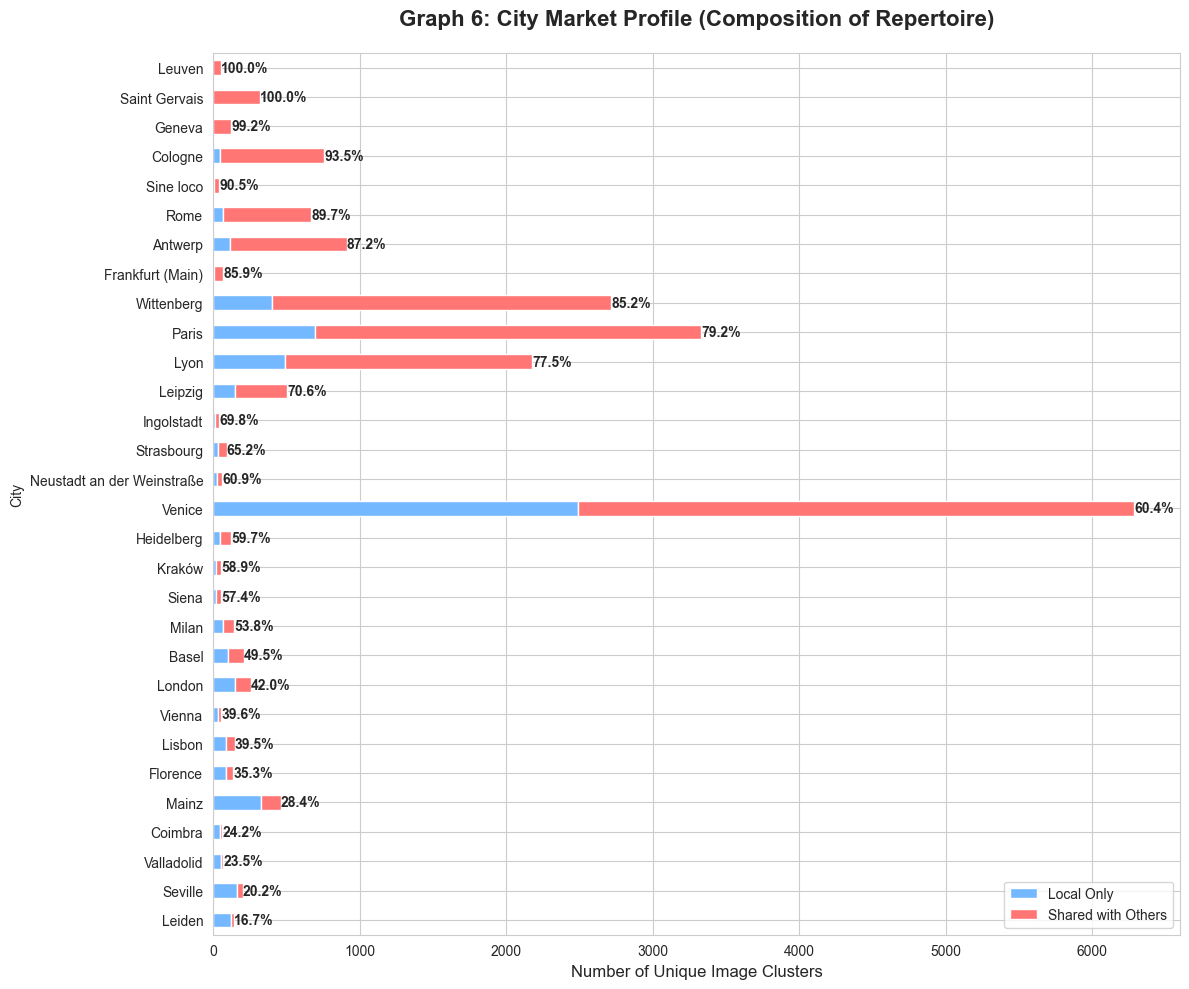

In [264]:
# 1. Identify Local vs. Shared Clusters
cluster_places = img_u.groupby('cluster_name')['place'].nunique()
local_clusters = cluster_places[cluster_places == 1].index
shared_clusters = cluster_places[cluster_places > 1].index

# 2. Calculate Composition per City for Top 30 cities
top_cities = img_u['place'].value_counts().head(30).index

city_data = []
for city in top_cities:
    city_subset = img_u[img_u['place'] == city]
    local_count = city_subset['cluster_name'].isin(local_clusters).sum()
    shared_count = city_subset['cluster_name'].isin(shared_clusters).sum()
    city_data.append({
        'City': city, 
        'Local': local_count, 
        'Shared': shared_count, 
        'Total': local_count + shared_count,
        'Shared_Pct': (shared_count / (local_count + shared_count)) * 100 if (local_count + shared_count) > 0 else 0
    })

df_viz = pd.DataFrame(city_data).sort_values('Shared_Pct')

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 10))
df_viz.plot(x='City', y=['Local', 'Shared'], kind='barh', stacked=True, ax=ax, color=['#74b9ff', '#ff7675'], edgecolor='white')

for i, (idx, row) in enumerate(df_viz.iterrows()):
    ax.text(row['Total'] + 2, i, f'{row["Shared_Pct"]:.1f}%', va='center', fontweight='bold')

ax.set_title('Graph 6: City Market Profile (Composition of Repertoire)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Unique Image Clusters', fontsize=12)
ax.legend(['Local Only', 'Shared with Others'], loc='lower right')
plt.tight_layout()
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/graph6_market_profile.png', dpi=300, bbox_inches='tight')
plt.show()

### Data Table: Sharing vs. Production Volume

Comparing the sharing percentage with the total number of books produced in each city highlights the 'Spoke' cities (high sharing, lower volume).

In [265]:
# Calculate book count per city
city_books = img_u.groupby('place')['bid'].nunique()

# Merge into our df_viz for final comparison
df_comparison = df_viz.copy()
df_comparison['Book_Volume'] = df_comparison['City'].map(city_books)

# Reorder logically by Sharing Percentage (Descending)
df_comparison = df_comparison[['City', 'Shared_Pct', 'Total', 'Book_Volume']].sort_values('Shared_Pct', ascending=False)

print('Ranking Cities by Dependency (Shared Woodblock Percentage):')
print('-' * 70)
print(f'{ "City":15} | {"Shared %":8} | {"Clusters":8} | {"Books":8}')
print('-' * 70)
for _, row in df_comparison.iterrows():
    print(f"{row["City"]:15} | {row["Shared_Pct"]:8.1f}% | {int(row["Total"]):8} | {int(row["Book_Volume"]):8}")


Ranking Cities by Dependency (Shared Woodblock Percentage):
----------------------------------------------------------------------
City            | Shared % | Clusters | Books   
----------------------------------------------------------------------
Leuven          |    100.0% |       51 |        1
Saint Gervais   |    100.0% |      319 |        3
Geneva          |     99.2% |      124 |        1
Cologne         |     93.5% |      758 |       15
Sine loco       |     90.5% |       42 |        2
Rome            |     89.7% |      669 |        6
Antwerp         |     87.2% |      911 |       22
Frankfurt (Main) |     85.9% |       71 |       13
Wittenberg      |     85.2% |     2719 |       48
Paris           |     79.2% |     3331 |       68
Lyon            |     77.5% |     2175 |       16
Leipzig         |     70.6% |      506 |       19
Ingolstadt      |     69.8% |       43 |        1
Strasbourg      |     65.2% |       92 |        5
Neustadt an der Weinstraße |     60.9% |       6

### Graph 7 — Book Market Profile (Unique vs. Shared Images Over Time)

Moving from the level of cities to individual books, this visualization examines the composition of each book's woodblock repertoire. By sorting books by their year of print, we can see if the dependency on shared material changed over time. Red segments represent shared (mobile) woodblocks, while blue segments represent images unique to that book.

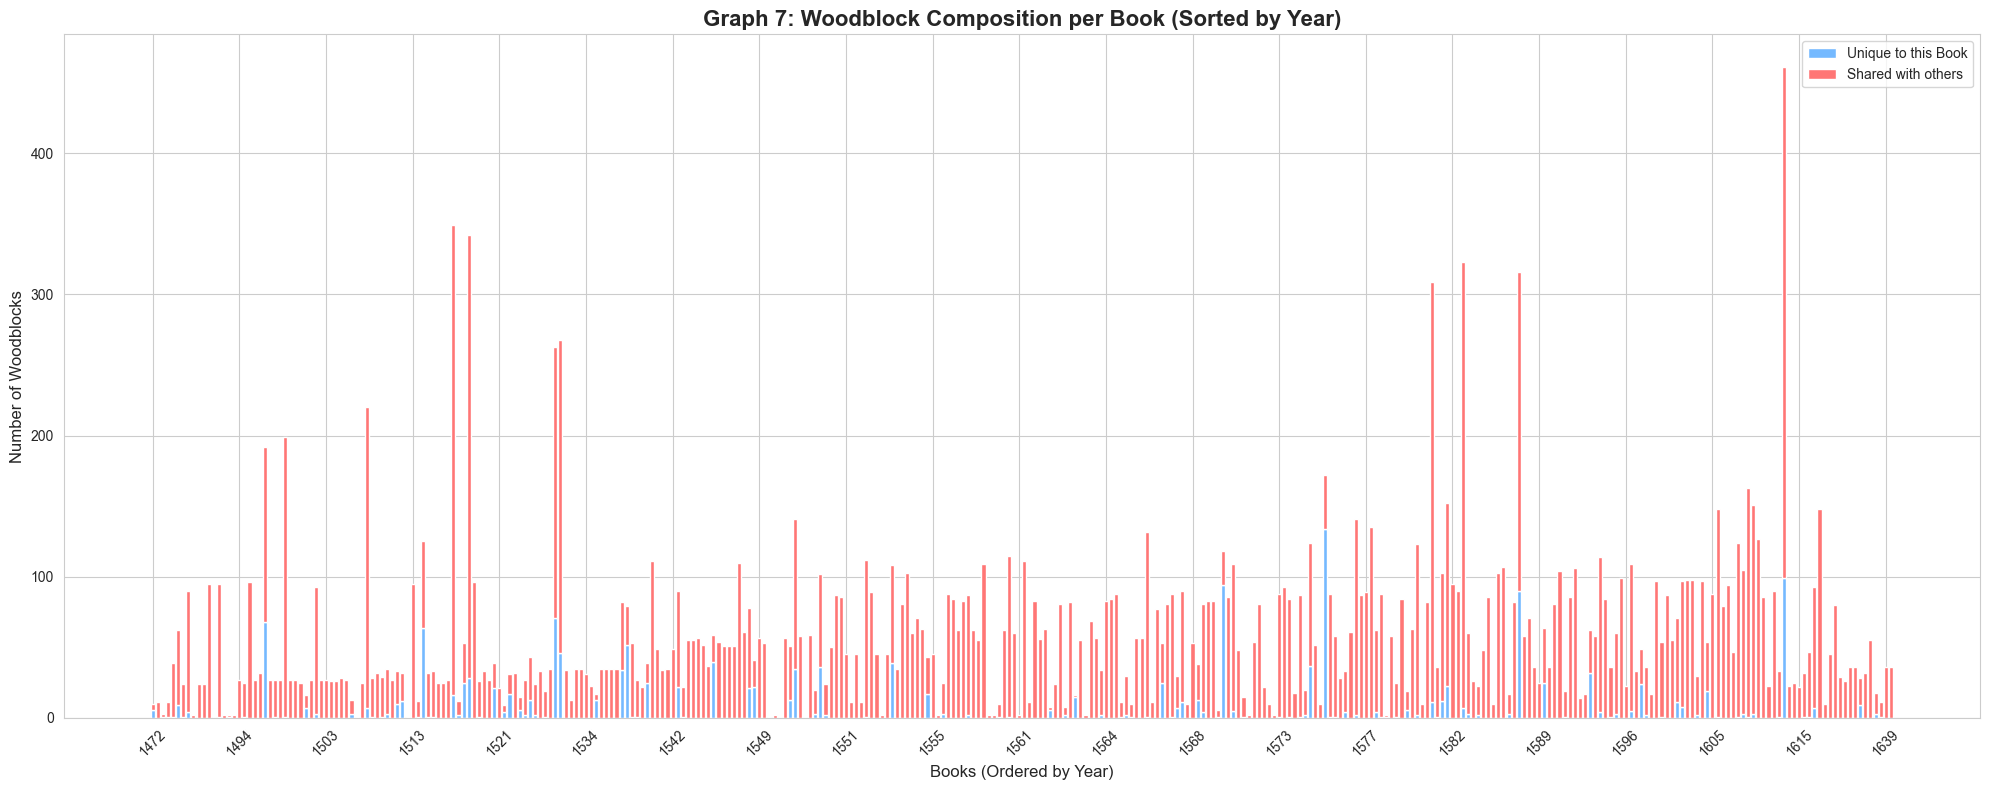

In [266]:
# 1. Identify Local vs. Shared Clusters
cluster_counts = img_u['cluster_name'].value_counts()
shared_clusters = cluster_counts[cluster_counts > 1].index
local_clusters = cluster_counts[cluster_counts == 1].index

# 2. Analyze each book
book_stats = []
for bid, group in img_u.groupby('bid'):
    local_count = group['cluster_name'].isin(local_clusters).sum()
    shared_count = group['cluster_name'].isin(shared_clusters).sum()
    book_stats.append({
        'bid': bid,
        'Local': local_count,
        'Shared': shared_count,
        'Total': local_count + shared_count
    })

df_books = pd.DataFrame(book_stats)

# 3. Merge with book metadata for Year and SORT
# Note: Ensure book_df is loaded or use metadata from img_u if possible
# For consistency we re-calculate or use existing book_df
df_books = df_books.merge(book_df[['bid', 'year']], on='bid').sort_values('year')

# 4. Plotting
fig, ax = plt.subplots(figsize=(20, 8))
df_books['x_idx'] = range(len(df_books))

ax.bar(df_books['x_idx'], df_books['Local'], label='Unique to this Book', color='#74b9ff')
ax.bar(df_books['x_idx'], df_books['Shared'], bottom=df_books['Local'], label='Shared with others', color='#ff7675')

# Ticks: Show years periodically
tick_indices = range(0, len(df_books), max(1, len(df_books)//20))
ax.set_xticks(tick_indices)
ax.set_xticklabels(df_books['year'].iloc[tick_indices], rotation=45)

ax.set_title('Graph 7: Woodblock Composition per Book (Sorted by Year)', fontsize=16, fontweight='bold')
ax.set_xlabel('Books (Ordered by Year)', fontsize=12)
ax.set_ylabel('Number of Woodblocks', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/graph7_book_composition.png', dpi=300, bbox_inches='tight')
plt.show()

### Graph 8 — Innovation Origins (Identifying the Hubs)

This visualization definitively identifies the 'Innovation Hubs' of the corpus by looking at every woodblock cluster and identifying its **Origin**—the city where it first appeared in our dataset. We then track the impact of that origin: how many other cities did woodblocks from that city travel to, and how long did they circulate?

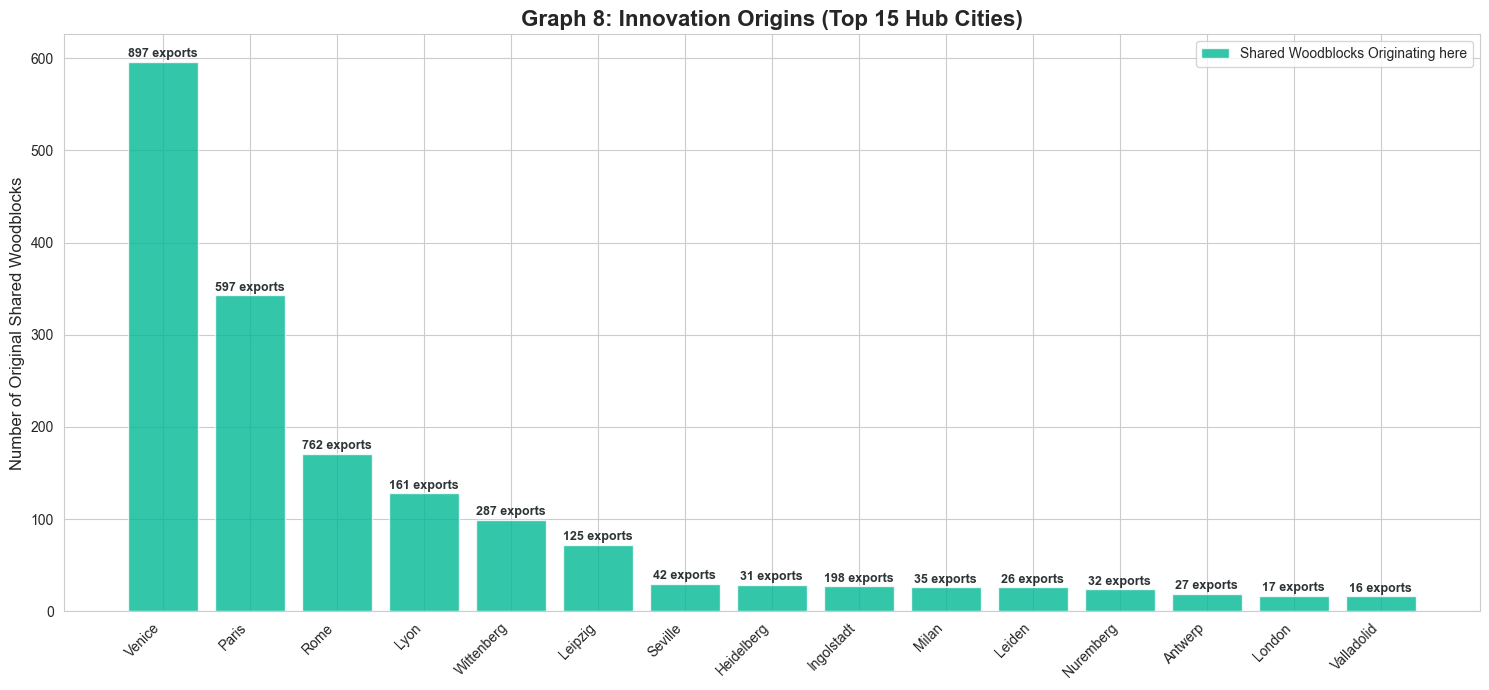

City Export Breakdown (Top Origins to Spokes):
             Total Origins  Impact (Total Exports)  max_years_active
origin_city                                                         
Venice                 596                     897         29.694631
Paris                  343                     597         45.641399
Rome                   171                     762         40.555556
Lyon                   128                     161          6.687500
Wittenberg              99                     287         54.383838
Leipzig                 72                     125         14.569444
Seville                 30                      42         33.600000
Heidelberg              29                      31         17.965517
Ingolstadt              27                     198         93.037037
Milan                   26                      35         64.653846


In [267]:
# 1. Extract the 'First Appearance' for every shared cluster
cluster_origins = []
shared_clusters = img_u['cluster_name'].value_counts()[img_u['cluster_name'].value_counts() > 1].index

for cluster in shared_clusters:
    group = img_u[img_u['cluster_name'] == cluster]
    origin_book = group.sort_values('year').iloc[0]
    origin_city = origin_book['place']
    origin_year = origin_book['year']
    
    # 2. Analyze the 'Copies' (Impact)
    copies = group[group['bid'] != origin_book['bid']]
    if not copies.empty:
        dest_cities = copies['place'].unique()
        max_time = copies['year'].max() - origin_year
        
        cluster_origins.append({
            'cluster': cluster,
            'origin_city': origin_city,
            'num_dest_cities': len(dest_cities),
            'max_years_active': max_time
        })

df_origins = pd.DataFrame(cluster_origins)

# 3. Summarize by City (The 'Innovation Index')
origin_summary = df_origins.groupby('origin_city').agg({
    'cluster': 'count',
    'num_dest_cities': 'sum',
    'max_years_active': 'mean'
}).rename(columns={'cluster': 'Total Origins', 'num_dest_cities': 'Impact (Total Exports)'})

origin_summary = origin_summary.sort_values('Total Origins', ascending=False).head(15)

# 4. Plotting
fig, ax = plt.subplots(figsize=(15, 7))
x_range = range(len(origin_summary))

bars = ax.bar(x_range, origin_summary['Total Origins'], color='#00b894', alpha=0.8, label='Shared Woodblocks Originating here')

# Annotate Impact
for i, (idx, row) in enumerate(origin_summary.iterrows()):
    ax.text(i, row['Total Origins'] + 5, f"{int(row['Impact (Total Exports)'])} exports", 
            ha='center', fontsize=9, fontweight='bold', color='#2d3436')

ax.set_xticks(x_range)
ax.set_xticklabels(origin_summary.index, rotation=45, ha='right')
ax.set_title('Graph 8: Innovation Origins (Top 15 Hub Cities)', fontsize=16, fontweight='bold')
ax.set_ylabel('Number of Original Shared Woodblocks', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/graph8_innovation_origins.png', dpi=300, bbox_inches='tight')
plt.show()
# 5. Numerical Breakdown of Destination (Sample)
print("City Export Breakdown (Top Origins to Spokes):")
print(origin_summary[['Total Origins', 'Impact (Total Exports)', 'max_years_active']].head(10).to_string())

### Innovation Market Summary: Originators vs. Pure Consumers

To understand the network structure of the market, we categorized cities into two groups: **Originators** (cities where woodblocks first appeared and then moved elsewhere) and **Pure Consumers** (cities that only printed woodblocks that had already appeared in other cities).

In [268]:
# 1. Identify ALL cities in the dataset
all_cities = img_u['place'].unique()

# 2. Get Origin Summary (from the previous plot logic)
final_summary = pd.DataFrame(index=all_cities)
final_summary.index.name = 'city'

# Map the origins from the previous logic
final_summary['Total Origins'] = final_summary.index.map(origin_summary['Total Origins']).fillna(0).astype(int)
final_summary['Impact (Exports)'] = final_summary.index.map(origin_summary['Impact (Total Exports)']).fillna(0).astype(int)

# 3. Add Book Count per city
book_counts = book_df['place'].value_counts()
final_summary['Books Printed'] = final_summary.index.map(book_counts).fillna(0).astype(int)

# 4. Categorize
originators = final_summary[final_summary['Total Origins'] > 0]
consumers = final_summary[final_summary['Total Origins'] == 0]

print(f"--- MARKET TOPOLOGY SUMMARY ---")
print(f"Total Cities in Dataset: {len(all_cities)}")
print(f"Originating Hubs (Cities that exported): {len(originators)}")
print(f"Pure Consumer Spokes (Cities with zero exports): {len(consumers)}")
print("\n--- FULL CITY EXPORT & PRODUCTION RANKING ---")
# Sort by Impact and then by Books Printed
print(final_summary.sort_values(['Impact (Exports)', 'Books Printed'], ascending=False).to_string())

--- MARKET TOPOLOGY SUMMARY ---
Total Cities in Dataset: 42
Originating Hubs (Cities that exported): 15
Pure Consumer Spokes (Cities with zero exports): 27

--- FULL CITY EXPORT & PRODUCTION RANKING ---
                            Total Origins  Impact (Exports)  Books Printed
city                                                                      
Venice                                596               897             70
Rome                                  171               762              6
Paris                                 343               597             69
Wittenberg                             99               287             48
Ingolstadt                             27               198              1
Lyon                                  128               161             16
Leipzig                                72               125             19
Seville                                30                42              5
Milan                                  26      

### Identifying the Innovative Editions: Books with the Highest Unique Content

While most books relied heavily on shared material, a small subset of editions introduced significant original visual material. This analysis ranks books by their **Unique Woodblock Count** and **Percentage**, identifying the primary drivers of visual innovation in the corpus.

In [269]:
# 1. Identify Local vs. Shared Clusters (Global Definition)
cluster_sizes = img_u['cluster_name'].value_counts()
local_clusters = cluster_sizes[cluster_sizes == 1].index

# 2. Re-calculate book-level stats including unique woodblocks
innovation_stats = []
for bid, group in img_u.groupby('bid'):
    total_images = len(group)
    unique_images = group['cluster_name'].isin(local_clusters).sum()
    innovation_stats.append({
        'bid': bid,
        'Total Images': total_images,
        'Unique Images': unique_images,
        'Innovation %': (unique_images / total_images) * 100 if total_images > 0 else 0
    })

df_innovation = pd.DataFrame(innovation_stats)

# 3. Merge with book metadata for display
# We use 'book' column instead of 'title'
df_innovation = df_innovation.merge(
    book_df[['bid', 'book', 'year', 'place', 'printers']], 
    on='bid'
)

# 4. Filter: Only consider books with at least 5 images to avoid outliers
df_sig = df_innovation[df_innovation['Total Images'] >= 5]

print("--- TOP 15 INNOVATIVE EDITIONS BY UNIQUE IMAGE COUNT ---")
print(df_sig.sort_values('Unique Images', ascending=False).head(15)[[
    'year', 'place', 'printers', 'Unique Images', 'Total Images', 'Innovation %'
]].to_string(index=False))

print("\n--- TOP 15 INNOVATIVE EDITIONS BY INNOVATION PERCENTAGE ---")
print(df_sig.sort_values('Innovation %', ascending=False).head(15)[[
    'year', 'place', 'printers', 'Innovation %', 'Unique Images', 'Total Images'
]].to_string(index=False))

--- TOP 15 INNOVATIVE EDITIONS BY UNIQUE IMAGE COUNT ---
 year      place                     printers  Unique Images  Total Images  Innovation %
 1575     Venice     Franceschi, Francesco de            134           172     77.906977
 1611      Mainz               Eltz, Reinhard             99           461     21.475054
 1569      Basel              Petri, Heinrich             94           118     79.661017
 1587     Venice     Franceschi, Francesco de             90           316     28.481013
 1531     Venice           Giunta, Lucantonio             71           263     26.996198
 1498      Paris                Marchant, Guy             68           192     35.416667
 1514      Milan           Ponte, Gottardo da             64           125     51.200000
 1537     Lisbon             Gaillard, German             52            79     65.822785
 1532      Paris               Morrhy, Gérard             46           268     17.164179
 1545    Seville                León, Juan de        

### Graph 9 — Intra-City Woodblock Exchange (Close Sharing Hubs)

Identifying cities where woodblocks are frequently shared between different printing institutions but remain within the same city. This 'Close Sharing' highlights urban centers with integrated material networks.

Task was destroyed but it is pending!
task: <Task pending name='Task-2208' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-2209' coro=<Kernel.shell_main() running at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/matplotlib/font_manager.py:1154: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  @staticmethod
Task was destroyed but it is pending!
task: <Task pending name='Task-2209' coro=<Kernel.shell_main() running at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597>

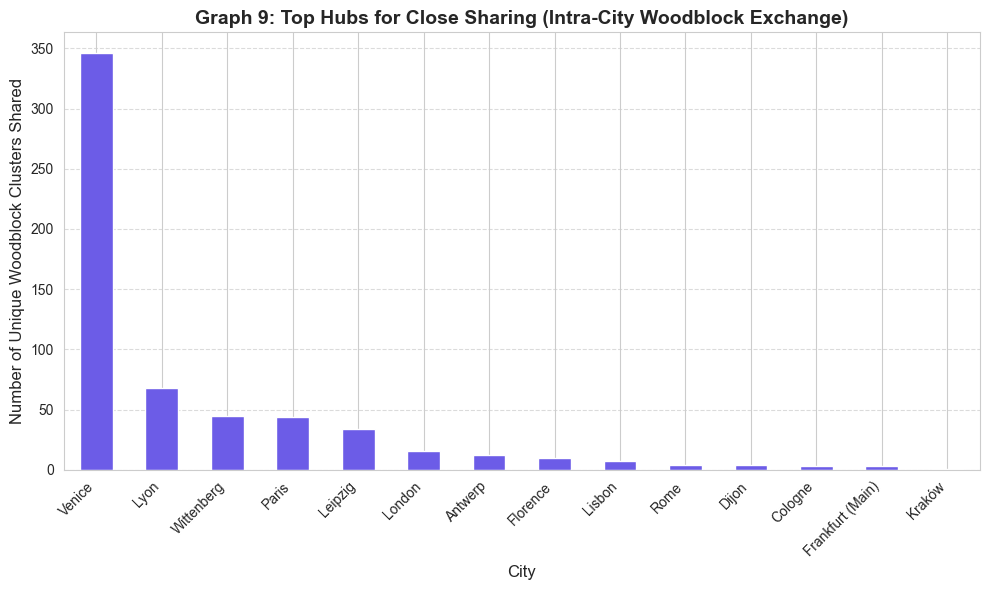

Total Close Sharing clusters identified: 597
Top 10 Cities for Local Mobility:
place
Venice        346
Lyon           68
Wittenberg     45
Paris          44
Leipzig        34
London         16
Antwerp        12
Florence       10
Lisbon          7
Rome            4
Name: count, dtype: int64


In [300]:
# Institutional Density Context for Close Sharing
def count_unique_entities(series):
    entities = set()
    for val in series.dropna():
        for item in str(val).split(';'):
            for sub in item.split(','):
                s = sub.strip()
                if s: entities.add(s)
    return len(entities)

institutional_stats = img_u.groupby('place').agg({
    'printers': count_unique_entities,
    'publishers': count_unique_entities
}).rename(columns={'printers': 'Total Printers', 'publishers': 'Total Publishers'})

# Identify Close Sharing clusters
cluster_stats = img_u.groupby('cluster_name').agg({
    'printers': 'nunique',
    'place': 'nunique'
}).rename(columns={'printers': 'nunique_printers', 'place': 'nunique_places'})

close_sharing_clusters = cluster_stats[(cluster_stats['nunique_printers'] > 1) & (cluster_stats['nunique_places'] == 1)].index
close_sharing_df = img_u[img_u['cluster_name'].isin(close_sharing_clusters)].drop_duplicates(subset=['cluster_name'])[['cluster_name', 'place']]

city_shared_counts = close_sharing_df['place'].value_counts().rename('Shared Woodblocks')

# Combine for Graph 9
graph9_df = pd.DataFrame(city_shared_counts).merge(institutional_stats, left_index=True, right_index=True, how='left')
top_cities = graph9_df.head(10)

# Visualization: Grouped Bar Chart
fig, ax = plt.subplots(figsize=(12, 7))
top_cities.plot(kind='bar', ax=ax, width=0.8, color=['#6c5ce7', '#fab1a0', '#55efc4'], edgecolor='white')

ax.set_title('Graph 9: Woodblock Sharing vs. Institutional Density', fontsize=16, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('City', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(frameon=False, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
fig.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/Graph_9_Institutional_Density.png', dpi=300)
plt.show()


### Graph 10 — Inter-City Woodblock Diffusion Network (DYNAMIC)

This interactive network visualizes 'Market Dependency' between all cities in the corpus. 
- **Interactivity**: You can drag nodes, scroll to zoom, and hover over elements for details.
- **Arrows**: Point from a city (spoke) to a hub if >80% of its shared woodblocks are found in that hub.
- **Node Size**: Proportional to the number of shared woodblock clusters in that city.

In [ ]:
import networkx as nx
from pyvis.network import Network
import IPython

# Identify inter-city shared clusters
cluster_places = img_u.groupby('cluster_name')['place'].nunique()
inter_city_clusters = cluster_places[cluster_places > 1].index
shared_df = img_u[img_u['cluster_name'].isin(inter_city_clusters)]
cluster_city_pairs = shared_df[['cluster_name', 'place']].drop_duplicates()

# Calculate totals per city and shared counts
city_totals = cluster_city_pairs.groupby('place')['cluster_name'].nunique()
pivot = pd.crosstab(cluster_city_pairs['cluster_name'], cluster_city_pairs['place'])

G = nx.DiGraph()
all_cities = img_u['place'].unique()
G.add_nodes_from(all_cities)

cities_with_shares = city_totals.index
for city_a in cities_with_shares:
    if city_totals[city_a] == 0: continue
    for city_b in cities_with_shares:
        if city_a == city_b: continue
        common = pivot[(pivot[city_a] > 0) & (pivot[city_b] > 0)].shape[0]
        if common / city_totals[city_a] > 0.8:
            G.add_edge(city_a, city_b, weight=common / city_totals[city_a])

# Create Pyvis Interactive Network
net = Network(height='800px', width='100%', bgcolor='#222222', font_color='white', directed=True, notebook=True, cdn_resources='remote')

for node in G.nodes():
    size = city_totals.get(node, 0)
    net.add_node(node, label=node, title=f'{node}: {size} shared clusters', size=max(10, size/2))

for source, target, data in G.edges(data=True):
    net.add_edge(source, target, value=data['weight'], title=f'{data["weight"]:.1%} dependency')

# Set physics for better spreading
net.force_atlas_2based()
net.show_buttons(filter_=['physics'])

# Save and Show
output_file = '/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/chpater6/Graph_10_Interactive_Diffusion.html'
net.show(output_file)

print(f"Interactive network saved to: {output_file}")
IPython.display.HTML(filename=output_file)
